In [2]:
import cv2
import matplotlib.pyplot as plt
import os

ModuleNotFoundError: No module named 'cv2'

Image dimensions: (256, 256, 3)
Image data type: uint8


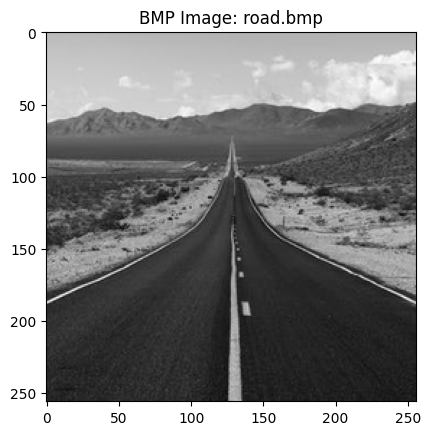

In [54]:
image_path = os.path.join('images', 'road.bmp')
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.title('BMP Image: road.bmp')
plt.axis('on')
print(f"Image dimensions: {image.shape}")
print(f"Image data type: {image.dtype}")
plt.show()


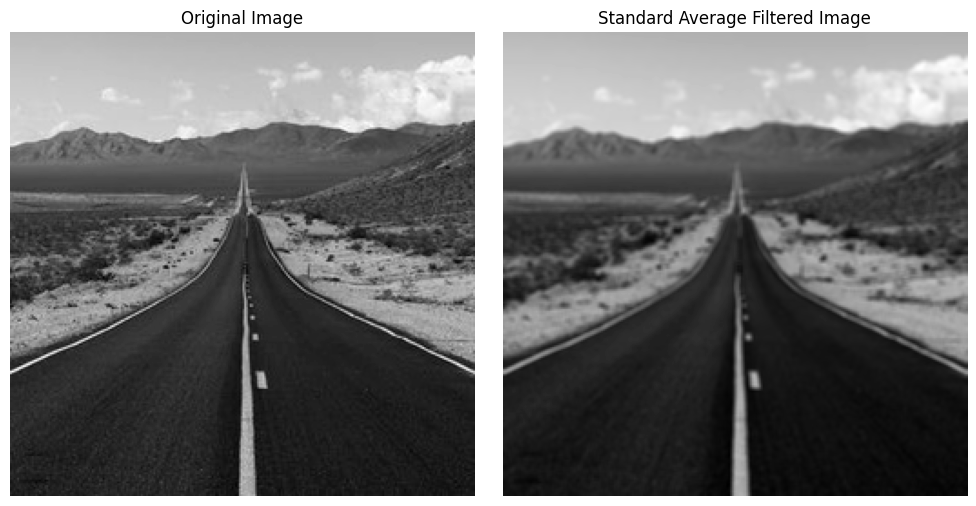

In [55]:
import numpy as np
from PIL import Image

image_path = os.path.join('images', 'road.bmp')
img = Image.open(image_path).convert('L')
img = np.array(img).astype(float)

k = 3
p = k // 2
h, w = img.shape
out2 = np.zeros((h, w))

for i in range(h):
    for j in range(w):
        s = 0
        c = 0
        for m in range(-p, p+1):
            for n in range(-p, p+1):
                if 0 <= i+m < h and 0 <= j+n < w:
                    s += img[i+m, j+n]
                    c += 1
        out2[i, j] = s / c

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(out2, cmap='gray')
axes[1].set_title('Standard Average Filtered Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()


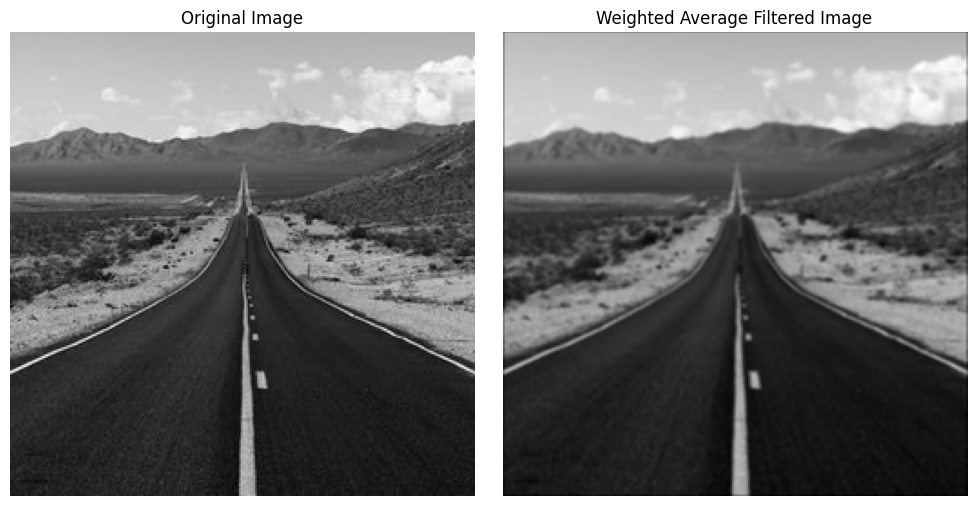

In [56]:
wgt = np.array([[1,2,1],
                [2,4,2],
                [1,2,1]], dtype=float)
wgt /= wgt.sum()
out = np.zeros((h, w))

for i in range(h):
    for j in range(w):
        s = 0
        for m in range(-p, p+1):
            for n in range(-p, p+1):
                if 0 <= i+m < h and 0 <= j+n < w:
                    s += img[i+m, j+n] * wgt[m+p, n+p]
        out[i, j] = s
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(out, cmap='gray')
axes[1].set_title('Weighted Average Filtered Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

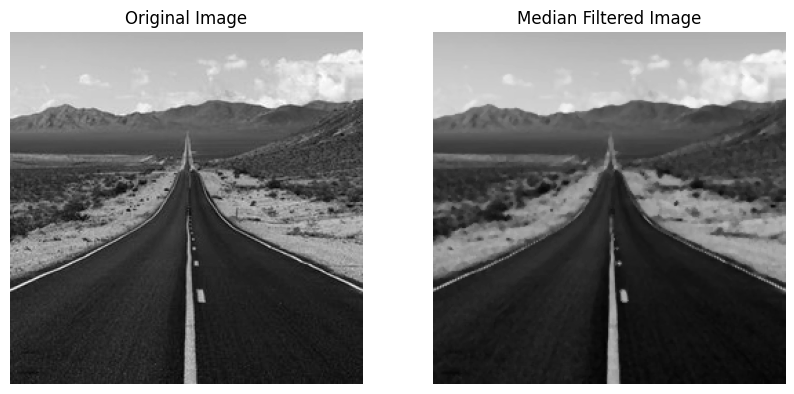

In [57]:
out = np.zeros((h, w))

for i in range(h):
    for j in range(w):
        vals = []
        for m in range(-p, p+1):
            for n in range(-p, p+1):
                if 0 <= i+m < h and 0 <= j+n < w:
                    vals.append(img[i+m, j+n])
        out[i, j] = np.median(vals)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(out, cmap='gray')
axes[1].set_title('Median Filtered Image')
axes[1].axis('off')

Text(0.5, 1.0, 'Laplacian Filtered Image')

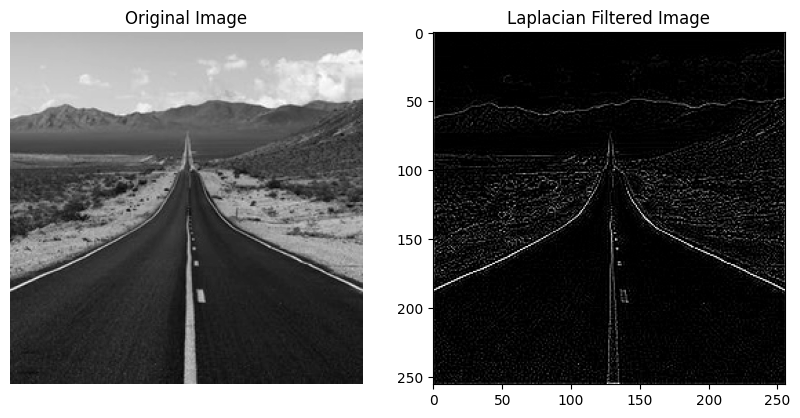

In [58]:
k = np.array([[0, -1, 0],
              [-1, 4, -1],
              [0, -1, 0]])

p = k.shape[0] // 2
h, w = img.shape
out = np.zeros((h, w))

for i in range(h):
    for j in range(w):
        s = 0
        for m in range(-p, p+1):
            for n in range(-p, p+1):
                if 0 <= i+m < h and 0 <= j+n < w:
                    s += img[i+m, j+n] * k[m+p, n+p]
        out[i, j] = s
out = np.clip(out, 0, 255)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(out, cmap='gray')
plt.title('Laplacian Filtered Image')

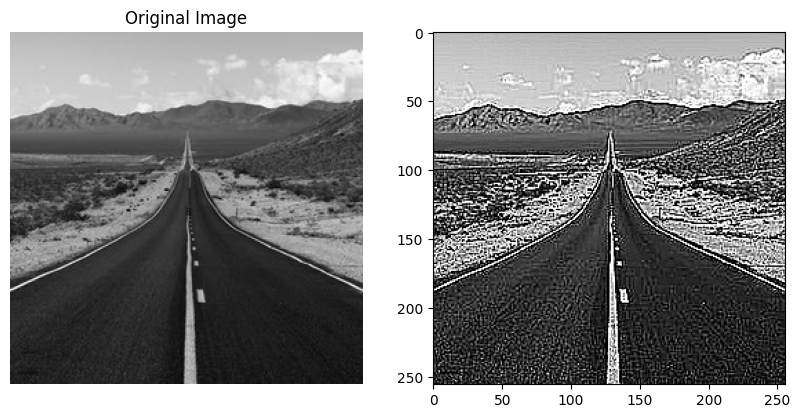

In [60]:
mask = img-out2
k=10
out = np.zeros((h, w))

# for i in range(h):
#     for j in range(w):
#         s = 0
#         for m in range(-p, p+1):
#             for n in range(-p, p+1):
#                 if 0 <= i+m < h and 0 <= j+n < w:
#                     s += img[i+m, j+n] * k[m+p, n+p]
#         out[i, j] = s

out = img + k*mask
out = np.clip(out, 0, 255)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(out, cmap='gray')